# 00 — Exploratory Data Analysis
## Project Caravela: Olist E-Commerce Analytics

**Purpose:** Schema verification, distribution checks, and data quality assessment of the `olist_analytics` BigQuery dataset (7 mart tables + 9 raw tables). Findings here inform the 3 analytical notebooks.

**No Parquet output** — this notebook is exploratory only.

In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from google.cloud import bigquery

# Load environment variables from .env
load_dotenv(Path("..") / ".env")

# BigQuery connection
project_id = os.environ["GCP_PROJECT_ID"]
dataset = os.environ.get("BIGQUERY_ANALYTICS_DATASET", "olist_analytics")
raw_dataset = os.environ.get("BIGQUERY_RAW_DATASET", "olist_raw")
client = bigquery.Client(project=project_id)

def run_query(sql: str) -> pd.DataFrame:
    """Execute a BigQuery SQL query and return a DataFrame."""
    return client.query(sql).to_dataframe()

print(f"Connected to project: {project_id}")
print(f"Analytics dataset: {dataset}  |  Raw dataset: {raw_dataset}")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

## 1. Table Row Counts

Row counts for all 9 raw source tables and 7 mart (analytics) tables.

In [2]:
# Raw tables (olist_raw dataset)
raw_tables = [
    "olist_customers_dataset", "olist_orders_dataset",
    "olist_order_items_dataset", "olist_order_payments_dataset",
    "olist_order_reviews_dataset", "olist_products_dataset",
    "olist_sellers_dataset", "olist_geolocation_dataset",
    "product_category_name_translation",
]

raw_counts = []
for t in raw_tables:
    df = run_query(f"SELECT COUNT(*) AS cnt FROM `{project_id}.{raw_dataset}.{t}`")
    raw_counts.append({"table": t, "rows": df["cnt"].iloc[0]})

# Mart tables (olist_analytics dataset)
mart_tables = [
    "fct_sales", "fct_reviews", "fct_payments",
    "dim_customers", "dim_products", "dim_sellers", "dim_date",
]

mart_counts = []
for t in mart_tables:
    df = run_query(f"SELECT COUNT(*) AS cnt FROM `{project_id}.{dataset}.{t}`")
    mart_counts.append({"table": t, "rows": df["cnt"].iloc[0]})

print("=== Raw Tables (olist_raw) ===")
raw_df = pd.DataFrame(raw_counts)
raw_df["rows"] = raw_df["rows"].apply(lambda x: f"{x:,}")
display(raw_df)

print("\n=== Mart Tables (olist_analytics) ===")
mart_df = pd.DataFrame(mart_counts)
mart_df["rows"] = mart_df["rows"].apply(lambda x: f"{x:,}")
display(mart_df)

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


...

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


=== Raw Tables (olist_raw) ===


,table,rows
0,olist_customers_dataset,"99,441"
1,olist_orders_dataset,"99,441"
2,olist_order_items_dataset,"112,650"
3,olist_order_payments_dataset,"103,886"
4,olist_order_reviews_dataset,"99,224"
5,olist_products_dataset,"32,951"
6,olist_sellers_dataset,"3,095"
7,olist_geolocation_dataset,"1,000,163"
8,product_category_name_translation,71



=== Mart Tables (olist_analytics) ===


,table,rows
0,fct_sales,"112,650"
1,fct_reviews,"98,410"
2,fct_payments,"103,883"
3,dim_customers,"96,096"
4,dim_products,"32,951"
5,dim_sellers,"3,095"
6,dim_date,"1,095"


## 2. Schema Inspection

Column names and data types for all mart tables, queried from `INFORMATION_SCHEMA.COLUMNS`.

In [3]:
schema_df = run_query(f"""
    SELECT table_name, column_name, data_type, is_nullable
    FROM `{project_id}.{dataset}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name IN ({', '.join(f"'{t}'" for t in mart_tables)})
    ORDER BY table_name, ordinal_position
""")

for table in mart_tables:
    subset = schema_df[schema_df["table_name"] == table][["column_name", "data_type", "is_nullable"]]
    print(f"\n{'='*50}")
    print(f"  {table}  ({len(subset)} columns)")
    print(f"{'='*50}")
    display(subset.reset_index(drop=True))

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



  fct_sales  (12 columns)


,column_name,data_type,is_nullable
0,order_id,STRING,YES
1,order_item_id,INT64,YES
2,product_id,STRING,YES
3,seller_id,STRING,YES
4,customer_unique_id,STRING,YES
5,date_key,DATE,YES
6,order_status,STRING,YES
7,price,FLOAT64,YES
8,freight_value,FLOAT64,YES
9,total_sale_amount,FLOAT64,YES



  fct_reviews  (7 columns)


,column_name,data_type,is_nullable
0,review_id,STRING,YES
1,order_id,STRING,YES
2,review_score,INT64,YES
3,review_comment_title,STRING,YES
4,review_comment_message,STRING,YES
5,date_key,DATE,YES
6,review_answer_timestamp,TIMESTAMP,YES


...

,column_name,data_type,is_nullable
0,product_id,STRING,YES
1,product_category_name_english,STRING,YES
2,product_name_length,INT64,YES
3,product_description_length,INT64,YES
4,product_photos_qty,INT64,YES
5,product_weight_g,INT64,YES
6,product_length_cm,FLOAT64,YES
7,product_height_cm,FLOAT64,YES
8,product_width_cm,FLOAT64,YES



  dim_sellers  (6 columns)


,column_name,data_type,is_nullable
0,seller_id,STRING,YES
1,seller_city,STRING,YES
2,seller_state,STRING,YES
3,seller_zip_code_prefix,STRING,YES
4,geolocation_lat,FLOAT64,YES
5,geolocation_lng,FLOAT64,YES



  dim_date  (6 columns)


,column_name,data_type,is_nullable
0,date_key,DATETIME,YES
1,year,INT64,YES
2,month,INT64,YES
3,day,INT64,YES
4,day_of_week,INT64,YES
5,quarter,INT64,YES


## 3. Null Distributions

Checking NULL counts for key analytical columns across mart tables. These inform threshold decisions for downstream analysis.

In [4]:
null_checks = {
    "fct_sales": [
        "order_delivered_customer_date", "order_estimated_delivery_date",
        "customer_unique_id", "product_id", "seller_id",
    ],
    "fct_reviews": [
        "review_score", "review_comment_title", "review_comment_message",
    ],
    "dim_customers": ["geolocation_lat", "geolocation_lng", "customer_state"],
    "dim_sellers": ["geolocation_lat", "geolocation_lng"],
    "dim_products": ["product_category_name_english"],
}

null_results = []
for table, cols in null_checks.items():
    agg_parts = ", ".join(
        f"COUNTIF({c} IS NULL) AS `{c}_null`" for c in cols
    )
    df = run_query(
        f"SELECT COUNT(*) AS total, {agg_parts} "
        f"FROM `{project_id}.{dataset}.{table}`"
    )
    total = df["total"].iloc[0]
    for c in cols:
        n = df[f"{c}_null"].iloc[0]
        null_results.append({
            "table": table,
            "column": c,
            "total_rows": total,
            "null_count": n,
            "null_pct": round(100 * n / total, 2),
        })

null_df = pd.DataFrame(null_results)
display(null_df[null_df["null_count"] > 0].reset_index(drop=True))
print(f"\nColumns with zero NULLs: {(null_df['null_count'] == 0).sum()} / {len(null_df)}")

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,table,column,total_rows,null_count,null_pct
0,fct_sales,order_delivered_customer_date,112650,2454,2.18
1,dim_customers,geolocation_lat,96096,269,0.28
2,dim_customers,geolocation_lng,96096,269,0.28
3,dim_sellers,geolocation_lat,3095,7,0.23
4,dim_sellers,geolocation_lng,3095,7,0.23



Columns with zero NULLs: 9 / 14


**Null observations:**
- `fct_sales.order_delivered_customer_date`: ~2,454 NULLs (~2.2%) — orders not yet delivered (shipped, canceled, etc.). Delivery metrics in notebook 03 must filter to delivered orders only.
- `dim_customers.geolocation_lat/lng`: 269 NULLs (~0.3%) — zip codes with no geolocation match. Choropleth maps are unaffected (aggregate by state, not coordinates).
- `dim_sellers.geolocation_lat/lng`: 7 NULLs (~0.2%) — minimal impact.
- `fct_reviews.review_comment_title/message`: 0 NULLs — but note the staging layer cast empty source values to empty strings (`''`), not NULL. We check empty-string prevalence below.

In [5]:
# Empty-string check for review comment fields
empty_check = run_query(f"""
    SELECT
        COUNT(*) AS total,
        COUNTIF(review_comment_title = '') AS title_empty,
        COUNTIF(review_comment_message = '') AS msg_empty
    FROM `{project_id}.{dataset}.fct_reviews`
""")
total = empty_check["total"].iloc[0]
t_empty = empty_check["title_empty"].iloc[0]
m_empty = empty_check["msg_empty"].iloc[0]
print(f"review_comment_title:   {t_empty:,} empty strings ({100*t_empty/total:.1f}% of {total:,})")
print(f"review_comment_message: {m_empty:,} empty strings ({100*m_empty/total:.1f}% of {total:,})")
print("\nThese are not NULLs — staging cast preserved them as empty strings.")

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


review_comment_title:   86,891 empty strings (88.3% of 98,410)
review_comment_message: 57,742 empty strings (58.7% of 98,410)

These are not NULLs — staging cast preserved them as empty strings.


## 4. Distribution Checks

### 4a. Review Score Distribution

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


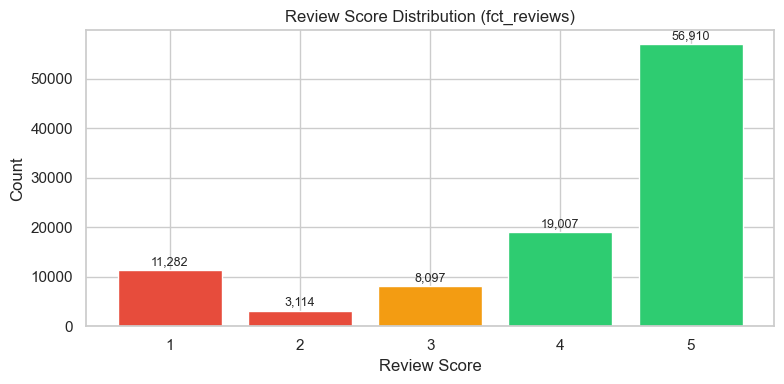

NPS proxy:  Promoters 77.1%  |  Passives 8.2%  |  Detractors 14.6%
NPS score:  62.5


In [6]:
review_dist = run_query(f"""
    SELECT review_score, COUNT(*) AS cnt
    FROM `{project_id}.{dataset}.fct_reviews`
    GROUP BY review_score
    ORDER BY review_score
""")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e74c3c", "#e74c3c", "#f39c12", "#2ecc71", "#2ecc71"]
bars = ax.bar(review_dist["review_score"], review_dist["cnt"], color=colors, edgecolor="white")
for bar, val in zip(bars, review_dist["cnt"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Review Score")
ax.set_ylabel("Count")
ax.set_title("Review Score Distribution (fct_reviews)")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# NPS proxy breakdown
total = review_dist["cnt"].sum()
detractors = review_dist[review_dist["review_score"].isin([1, 2])]["cnt"].sum()
passives = review_dist[review_dist["review_score"] == 3]["cnt"].sum()
promoters = review_dist[review_dist["review_score"].isin([4, 5])]["cnt"].sum()
nps = 100 * (promoters - detractors) / total
print(f"NPS proxy:  Promoters {100*promoters/total:.1f}%  |  Passives {100*passives/total:.1f}%  |  Detractors {100*detractors/total:.1f}%")
print(f"NPS score:  {nps:.1f}")

### 4b. Payment Type Distribution

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


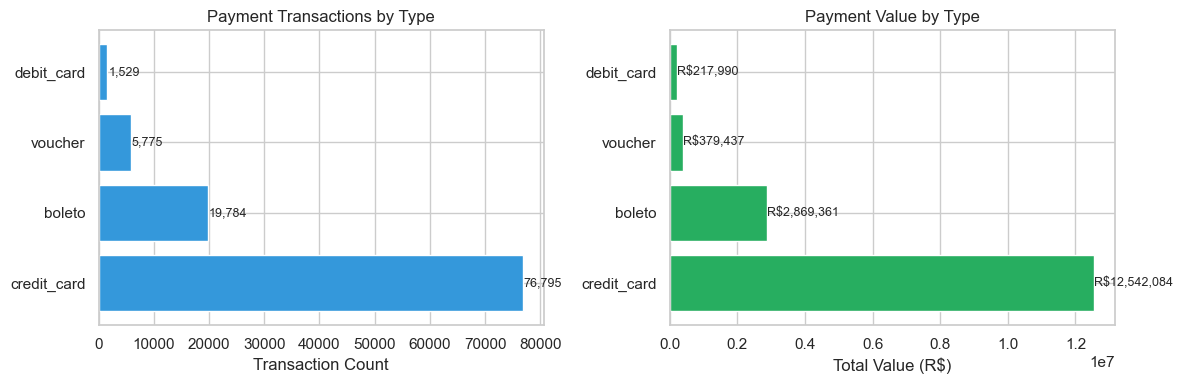

,payment_type,cnt,total_value
0,credit_card,76795,12542084.19
1,boleto,19784,2869361.27
2,voucher,5775,379436.87
3,debit_card,1529,217989.79


In [7]:
payment_dist = run_query(f"""
    SELECT payment_type, COUNT(*) AS cnt,
           ROUND(SUM(payment_value), 2) AS total_value
    FROM `{project_id}.{dataset}.fct_payments`
    GROUP BY payment_type
    ORDER BY cnt DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count distribution
axes[0].barh(payment_dist["payment_type"], payment_dist["cnt"], color="#3498db")
axes[0].set_xlabel("Transaction Count")
axes[0].set_title("Payment Transactions by Type")
for i, (cnt, ptype) in enumerate(zip(payment_dist["cnt"], payment_dist["payment_type"])):
    axes[0].text(cnt + 200, i, f"{cnt:,}", va="center", fontsize=9)

# Value distribution
axes[1].barh(payment_dist["payment_type"], payment_dist["total_value"], color="#27ae60")
axes[1].set_xlabel("Total Value (R$)")
axes[1].set_title("Payment Value by Type")
for i, val in enumerate(payment_dist["total_value"]):
    axes[1].text(val + 5000, i, f"R${val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()
display(payment_dist)

### 4c. Order Status Distribution

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


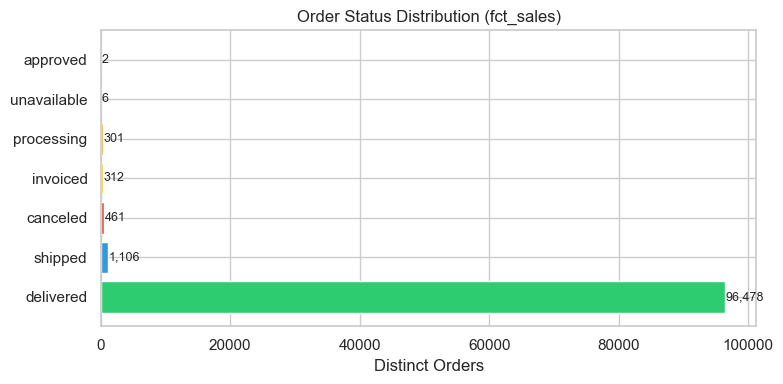

,order_status,orders,pct
0,delivered,96478,97.78
1,shipped,1106,1.12
2,canceled,461,0.47
3,invoiced,312,0.32
4,processing,301,0.31
5,unavailable,6,0.01
6,approved,2,0.0


In [8]:
status_dist = run_query(f"""
    SELECT order_status, COUNT(DISTINCT order_id) AS orders
    FROM `{project_id}.{dataset}.fct_sales`
    GROUP BY order_status
    ORDER BY orders DESC
""")

fig, ax = plt.subplots(figsize=(8, 4))
status_colors = [
    "#2ecc71", "#3498db", "#e74c3c", "#f1c40f",
    "#f39c12", "#c0392b", "#95a5a6", "#bdc3c7",
]
bars = ax.barh(status_dist["order_status"], status_dist["orders"],
               color=status_colors[:len(status_dist)])
for bar, val in zip(bars, status_dist["orders"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlabel("Distinct Orders")
ax.set_title("Order Status Distribution (fct_sales)")
plt.tight_layout()
plt.show()

# Percentage breakdown
total_orders = status_dist["orders"].sum()
status_dist["pct"] = (100 * status_dist["orders"] / total_orders).round(2)
display(status_dist)

## 5. Data Cut Awareness (ASMP-025)

Monthly order volume to identify the meaningful analysis window and data cut artefacts.

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


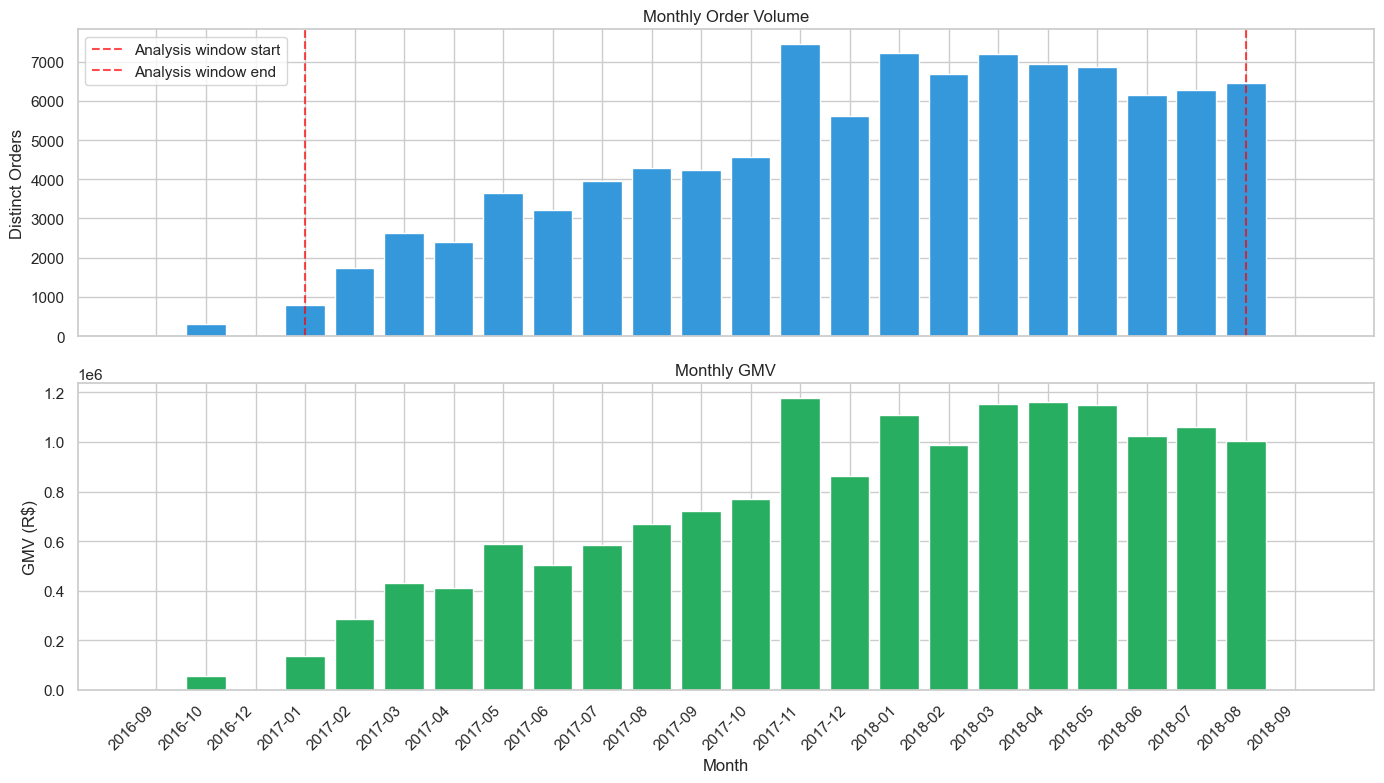

Data cut artefacts:
  2016-09: 3 orders (ARTEFACT — exclude from trend analysis)
  2016-12: 1 orders (ARTEFACT — exclude from trend analysis)
  2018-09: 1 orders (ARTEFACT — exclude from trend analysis)

Meaningful analysis window: Jan 2017 – Aug 2018


In [9]:
monthly = run_query(f"""
    SELECT
        d.year, d.month,
        COUNT(DISTINCT s.order_id) AS orders,
        ROUND(SUM(s.total_sale_amount), 2) AS gmv
    FROM `{project_id}.{dataset}.fct_sales` s
    JOIN `{project_id}.{dataset}.dim_date` d ON s.date_key = d.date_key
    GROUP BY d.year, d.month
    ORDER BY d.year, d.month
""")
monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Order volume
axes[0].bar(monthly["period"], monthly["orders"], color="#3498db", edgecolor="white")
axes[0].set_ylabel("Distinct Orders")
axes[0].set_title("Monthly Order Volume")
axes[0].axvline(x="2017-01", color="red", linestyle="--", alpha=0.7, label="Analysis window start")
axes[0].axvline(x="2018-08", color="red", linestyle="--", alpha=0.7, label="Analysis window end")
axes[0].legend()

# GMV
axes[1].bar(monthly["period"], monthly["gmv"], color="#27ae60", edgecolor="white")
axes[1].set_ylabel("GMV (R$)")
axes[1].set_title("Monthly GMV")
axes[1].set_xlabel("Month")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Flag data cut artefacts
print("Data cut artefacts:")
for _, row in monthly.iterrows():
    if row["orders"] < 50:
        print(f"  {row['period']}: {row['orders']} orders (ARTEFACT — exclude from trend analysis)")
print(f"\nMeaningful analysis window: Jan 2017 – Aug 2018")

### Data Cut Summary

| Period | Orders (fct_sales) | Note |
|---|---|---|
| 2016-09 | 3 | Pre-launch test orders |
| 2016-10 | 308 | Platform soft launch |
| 2016-11 | 0 | No orders in `fct_sales` |
| 2016-12 | 1 | Single order |
| **2017-01 to 2018-08** | **~98k** | **Meaningful analysis window** |
| 2018-09 | 1 | Data cut artefact (raw `olist_orders_dataset` has 16 order headers, but only 1 has items in `fct_sales`) |
| 2018-10 | 0 | Data cut artefact (raw table has 4 order headers, none with items) |

- **Peak month**: Nov 2017 (~7,451 orders) — Black Friday effect
- **Growth trend**: Steady increase from Jan 2017 (~789 orders) to early 2018 (~7,200/month), then plateau
- 2016 orders (312 total) are retained for RFM Recency calculation only — excluded from all trend analyses

> **Currency note:** All monetary values are in Brazilian Real (R$). For USD reference: R$15.8M total GMV ≈ USD 4.3M at the 2018 average exchange rate of ~R$3.65/USD.

## 6. Additional Distribution Checks

### 6a. Customer Purchase Frequency

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


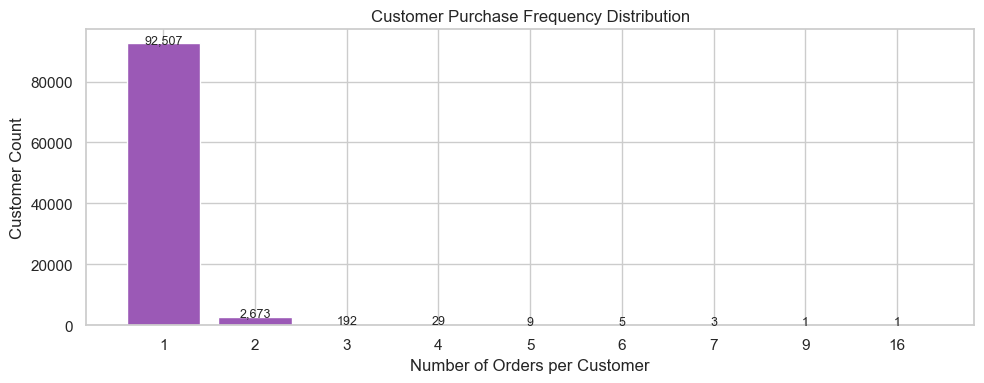

Single-purchase customers: 92,507 / 95,420 (96.9%)
Repeat customers: 2,913 (3.1%)

This confirms quintile-based F-scoring would collapse. Using 3-tier: F1=1, F2=2, F3=3+ orders.


In [10]:
# Purchase frequency — critical for RFM F-tier design (notebook 02)
freq = run_query(f"""
    SELECT frequency, COUNT(*) AS customers
    FROM (
        SELECT customer_unique_id, COUNT(DISTINCT order_id) AS frequency
        FROM `{project_id}.{dataset}.fct_sales`
        GROUP BY customer_unique_id
    )
    GROUP BY frequency
    ORDER BY frequency
""")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq["frequency"].astype(str), freq["customers"], color="#9b59b6", edgecolor="white")
for i, (f, c) in enumerate(zip(freq["frequency"], freq["customers"])):
    ax.text(i, c + 200, f"{c:,}", ha="center", fontsize=9)
ax.set_xlabel("Number of Orders per Customer")
ax.set_ylabel("Customer Count")
ax.set_title("Customer Purchase Frequency Distribution")
plt.tight_layout()
plt.show()

total_customers = freq["customers"].sum()
single_purchase = freq[freq["frequency"] == 1]["customers"].iloc[0]
print(f"Single-purchase customers: {single_purchase:,} / {total_customers:,} ({100*single_purchase/total_customers:.1f}%)")
print(f"Repeat customers: {total_customers - single_purchase:,} ({100*(total_customers - single_purchase)/total_customers:.1f}%)")
print(f"\nThis confirms quintile-based F-scoring would collapse. Using 3-tier: F1=1, F2=2, F3=3+ orders.")

### 6b. Regional Distribution

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


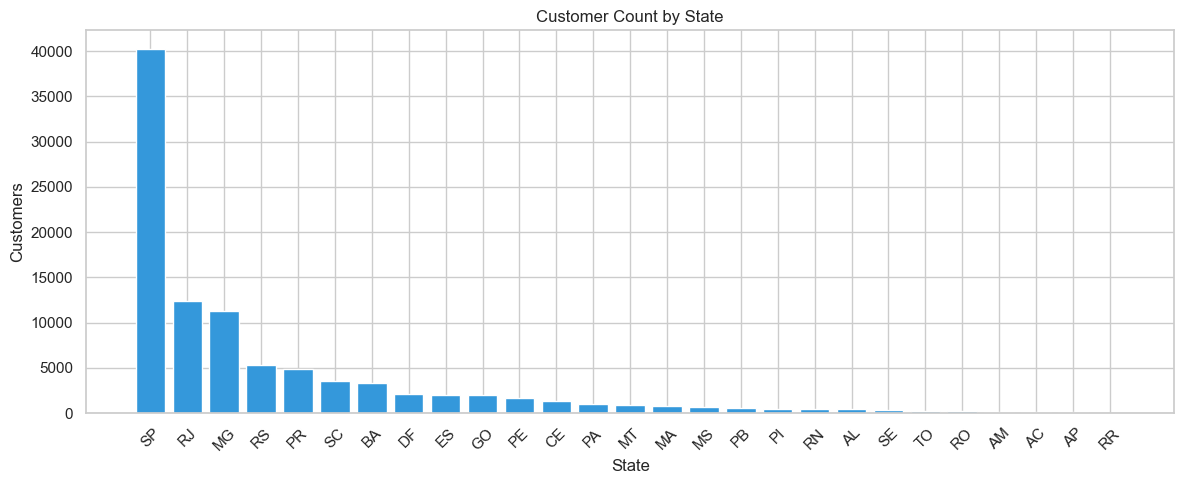

Top 5 states account for 77.1% of customers


,customer_state,customers
0,SP,40293
1,RJ,12377
2,MG,11253
3,RS,5277
4,PR,4880
5,SC,3531
6,BA,3276
7,DF,2073
8,ES,1963
9,GO,1951


In [11]:
# Customer distribution by state — feeds into notebook 03 geographic analysis
state_dist = run_query(f"""
    SELECT customer_state, COUNT(*) AS customers
    FROM `{project_id}.{dataset}.dim_customers`
    GROUP BY customer_state
    ORDER BY customers DESC
""")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(state_dist["customer_state"], state_dist["customers"], color="#3498db", edgecolor="white")
ax.set_xlabel("State")
ax.set_ylabel("Customers")
ax.set_title("Customer Count by State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Top 5 states account for {100 * state_dist.head(5)['customers'].sum() / state_dist['customers'].sum():.1f}% of customers")
display(state_dist.head(10))

### 6c. Delivery Performance Overview

In [12]:
# Delivery timing — feeds into notebook 03
delivery = run_query(f"""
    SELECT
        COUNT(DISTINCT order_id) AS total_delivered,
        COUNTIF(order_delivered_customer_date <= order_estimated_delivery_date) AS on_time,
        COUNTIF(order_delivered_customer_date > order_estimated_delivery_date) AS late,
        ROUND(AVG(TIMESTAMP_DIFF(order_delivered_customer_date, order_estimated_delivery_date, DAY)), 1) AS avg_delay_days
    FROM (
        SELECT DISTINCT order_id, order_delivered_customer_date, order_estimated_delivery_date
        FROM `{project_id}.{dataset}.fct_sales`
        WHERE order_delivered_customer_date IS NOT NULL
    )
""")

total = delivery["total_delivered"].iloc[0]
on_time = delivery["on_time"].iloc[0]
late = delivery["late"].iloc[0]
avg_delay = delivery["avg_delay_days"].iloc[0]

print(f"Delivered orders: {total:,}")
print(f"On-time: {on_time:,} ({100*on_time/total:.1f}%)")
print(f"Late:    {late:,} ({100*late/total:.1f}%)")
print(f"Avg delay (all delivered): {avg_delay} days")
print(f"\nNote: negative delay = delivered early. Notebook 03 uses 5 delay bins for correlation analysis.")

/opt/anaconda3/envs/assignment2/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Delivered orders: 96,476
On-time: 88,649 (91.9%)
Late:    7,827 (8.1%)
Avg delay (all delivered): -11.0 days

Note: negative delay = delivered early. Notebook 03 uses 5 delay bins for correlation analysis.


## 7. Data Quality Notes

### Issues Identified

1. **Review comment fields are empty strings, not NULLs.** The dbt staging layer cast source NULLs to `''`. ~88.3% of titles and ~58.7% of messages are empty strings. For text analysis (if needed), filter on `review_comment_message != ''`.

2. **Delivery timestamps are order-level, repeated across item rows.** `fct_sales` is item-granularity — `order_delivered_customer_date` and `order_estimated_delivery_date` are the same for all items in an order. Always use `COUNT(DISTINCT order_id)` for delivery rate calculations to avoid inflating counts by item multiplicity.

3. **~2.2% of orders have NULL delivery dates.** These are non-delivered orders (shipped, canceled, invoiced, processing, etc.). Delivery metrics must filter to `order_delivered_customer_date IS NOT NULL`.

4. **Customer geolocation coverage is 99.7%.** 269 of 96,096 customers lack lat/lng coordinates. State-level analysis is unaffected (0 NULLs on `customer_state`).

5. **`product_category_name_english` has no NULLs** — COALESCE in staging resolved all missing translations to `'uncategorized'`. Use this column exclusively (not `product_category_name`).

6. **`fct_payments` excludes `payment_type = 'not_defined'`** (3 zero-value rows removed in staging) and clamps `payment_installments = 0` to 1. This is already clean in the mart layer.

7. **`dim_date.date_key` reports as DATETIME in `INFORMATION_SCHEMA`** (see §2 above), despite being generated by `dbt_utils.date_spine` which nominally produces DATE. This is a BigQuery metadata quirk — the column functions as DATE in all joins and filters (`fct_sales.date_key` is typed DATE). No practical impact, but schema documentation should note this discrepancy.

### Data Integrity Confirmations

- All FK columns in `fct_sales` have 0 NULLs (`customer_unique_id`, `product_id`, `seller_id`)
- `dim_date` spans 2016-01-01 to 2018-12-31 (1,095 rows) — full coverage with buffer
- `fct_reviews` has 98,410 rows after dedup (vs 99,224 raw) — 814 duplicate `review_id` values removed

## 8. Findings Summary for Analytical Notebooks

### → `01_sales_analysis.ipynb` (Metrics 1, 2, 6, 7, 8)
- **Observation window**: Jan 2017 – Aug 2018 (exclude 2016 + 2018-09)
- Credit card dominates payments (~74% of transactions). Installment analysis relevant for credit card only.
- Delivered orders make up ~97.8% — cancellation rate is low but trackable over time.
- `fct_sales` is item-granularity — use `COUNT(DISTINCT order_id)` for order-level metrics.

### → `02_customer_analysis.ipynb` (Metrics 3, 5, 9)
- **96.9% single-purchase customers** — quintile F-scoring is meaningless. Use 3-tier: F1/F2/F3.
- RFM reference date: `2018-08-31` (hardcoded). Retain 2016 orders for Recency only.
- Review scores are J-shaped (skewed toward 5). NPS proxy score is positive but moderate.
- Empty-string review comments should not be confused with NULLs.

### → `03_geo_seller_analysis.ipynb` (Metrics 4, 10, 11)
- SP dominates customer distribution. Top 5 states ≈ 75%+ of all customers.
- Delivery on-time rate and delay require `DISTINCT order_id` — item-level inflation is the biggest trap.
- ~2.2% of orders lack delivery dates — filter these out for delivery performance metrics.
- Min 30 orders threshold per state/region to suppress sparse cells.